# Breast Cancer Gene Expression Predictor - Training model
### using pytorch
by mikeph_

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, auc
from sklearn.decomposition import PCA

GSE45827 = "data/GSE45827_series_matrix.txt"

df = pd.read_csv(
    GSE45827,
    sep="\t",
    comment="!",
    index_col=0
)

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"

def starting_msg():
    print("GEO Breast Cancer Classifier")
    print("by mikeph52 2026\n")
    print("Printing dataset head.\n")
    print(f"Using {device} device\n")
    print(df.head())

starting_msg()
# transpose df
X = df.T

# convert string to nummeric
X = X.apply(pd.to_numeric, errors="coerce")
X = X.fillna(X.mean())

print("Expression shape:", X.shape)

labels = []

with open(GSE45827) as f:
    for line in f:
        if line.startswith("!Sample_characteristics_ch1"):
            values = line.strip().split("\t")[1:]
            for v in values:
                if ("cancer" in v.lower()) or ("tumor" in v.lower()):
                    labels.append(1)
                else:
                    labels.append(0)
            break  # IMPORTANT: stop after first matching line

y = np.array(labels)

print("Labels length:", len(y))
assert X.shape[0] == y.shape[0], \
    f"Mismatch: {X.shape[0]} samples vs {y.shape[0]} labels"

print("Samples and labels aligned")

GEO Breast Cancer Classifier
by mikeph52 2026

Printing dataset head.

Using mps device

           GSM1116084  GSM1116085  GSM1116086  GSM1116087  GSM1116088  \
ID_REF                                                                  
1007_s_at     9.47065     9.67440    10.20800    10.11420    11.16360   
1053_at       8.36311     8.72194     7.78601     9.44537     7.71242   
117_at        5.95426     7.02523     6.39671     4.56023     5.29008   
1294_at       6.02119     7.24581     6.85310     5.42786     7.51120   
1316_at       3.22997     3.29352     3.26204     3.34766     3.59086   

           GSM1116089  GSM1116090  GSM1116091  GSM1116092  GSM1116093  ...  \
ID_REF                                                                 ...   
1007_s_at    10.00690     9.53932     9.00187     6.54074    10.35510  ...   
1053_at       7.84274     7.56238     8.01540     9.37874     9.45426  ...   
117_at        6.21590     6.42180     6.23554     5.43541     3.85652  ...   
1294_at  

## Train Model

Selected features: 200
Epoch [100/1000], Loss: 0.1443
Epoch [200/1000], Loss: 0.1019
Epoch [300/1000], Loss: 0.0804
Epoch [400/1000], Loss: 0.0666
Epoch [500/1000], Loss: 0.0567
Epoch [600/1000], Loss: 0.0492
Epoch [700/1000], Loss: 0.0432
Epoch [800/1000], Loss: 0.0385
Epoch [900/1000], Loss: 0.0346
Epoch [1000/1000], Loss: 0.0314


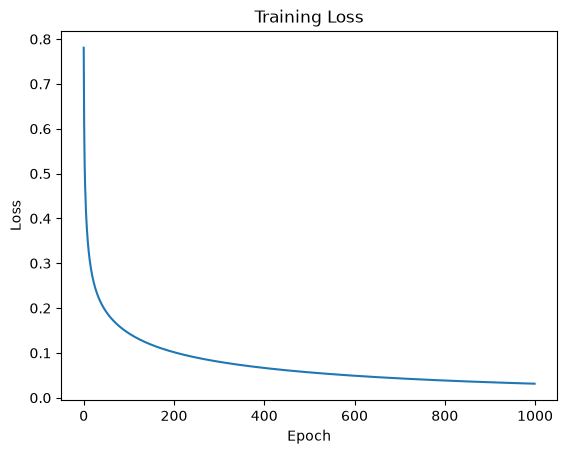

In [2]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

selector = SelectKBest(score_func=f_classif, k=200)

X_train_sel = selector.fit_transform(X_train, y_train)
X_test_sel = selector.transform(X_test)

print("Selected features:", X_train_sel.shape[1])

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled = scaler.transform(X_test_sel)

# converting to tensors
X_train_scaled = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_scaled = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)
# move to device
X_train_scaled = X_train_scaled.to(device)
X_test_scaled = X_test_scaled.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)
# the model
class LogisticRegression(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return self.linear(x) # No sigmoid

model = LogisticRegression(input_dim=X_train_scaled.shape[1]).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
criterion = nn.BCEWithLogitsLoss()

num_epochs = 1000
losses = []

for epoch in range(num_epochs):
    logits = model(X_train_scaled)
    loss = criterion(logits, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()



## Evaluation

In [3]:
model.eval()

# disable gradient computation for evaluation
with torch.no_grad():
    test_logits = model(X_test_scaled)
    y_pred_prob = torch.sigmoid(test_logits)
    y_pred_class = (y_pred_prob >= 0.5).float()

accuracy = (y_pred_class.eq(y_test).sum() / y_test.shape[0]).item()
print(f"Test Accuracy: {accuracy:.4f}")
# more sanity checks
print(y_pred_class.eq(y_test).sum().item())
print(y_test.shape[0])
print(y_test.sum().item())
# convert tensors to numeric back again
y_test_np = y_test.cpu().numpy()
y_pred_prob_np = y_pred_prob.cpu().numpy()
y_pred_class_np = y_pred_class.cpu().numpy()

print("ROC-AUC:", roc_auc_score(y_test_np, y_pred_prob_np))
print(classification_report(y_test_np, y_pred_class_np))

Test Accuracy: 0.9677
30
31
26.0
ROC-AUC: 1.0
              precision    recall  f1-score   support

         0.0       0.83      1.00      0.91         5
         1.0       1.00      0.96      0.98        26

    accuracy                           0.97        31
   macro avg       0.92      0.98      0.94        31
weighted avg       0.97      0.97      0.97        31



## Gene expression

In [4]:
selected_genes = X.columns[selector.get_support()]
coefficient = model.linear.weight.data.cpu().numpy().flatten() # for stupid GPUs

gene_importance = (
    pd.DataFrame({
        "Gene": selected_genes,
        "Weight": coefficient
    })
    .sort_values("Weight", ascending=False)
)

gene_importance.head(10)

,Gene,Weight
144,234032_at,0.230022
63,201721_s_at,0.225002
139,232963_at,0.223395
133,231205_at,0.220461
158,237864_at,0.219823
166,239238_at,0.218296
106,216834_at,0.213858
98,214291_at,0.213238
155,237107_at,0.211119
140,233595_at,0.206073


In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_aucs = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X, y)):
    # 1. Split X, y for this fold
    X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
    y_train_fold, y_val_fold = y[train_idx], y[val_idx]

    # 2. Fit selector + scaler on TRAINING portion of this fold only
    selector_fold = SelectKBest(score_func=f_classif, k=200)
    X_train_fold_sel = selector_fold.fit_transform(X_train_fold, y_train_fold)
    X_val_fold_sel = selector_fold.transform(X_val_fold)

    scaler_fold = StandardScaler()
    X_train_fold_scaled = scaler_fold.fit_transform(X_train_fold_sel)
    X_val_fold_scaled = scaler_fold.transform(X_val_fold_sel)

    # 3. Convert to tensors
    X_train_t = torch.tensor(X_train_fold_scaled, dtype=torch.float32).to(device)
    X_val_t = torch.tensor(X_val_fold_scaled, dtype=torch.float32).to(device)
    y_train_t = torch.tensor(y_train_fold, dtype=torch.float32).view(-1, 1).to(device)
    y_val_t = torch.tensor(y_val_fold, dtype=torch.float32).view(-1, 1).to(device)

    # 4. Fresh model, optimizer, and loss function for this fold
    fold_model = LogisticRegression(input_dim=X_train_t.shape[1]).to(device)
    fold_optimizer = torch.optim.SGD(fold_model.parameters(), lr=0.01)
    fold_criterion = nn.BCEWithLogitsLoss()

    # 5. Train
    fold_epochs = 300
    for epoch in range(fold_epochs):
        logits = fold_model(X_train_t)
        loss = fold_criterion(logits, y_train_t)

        fold_optimizer.zero_grad()
        loss.backward()
        fold_optimizer.step()

    # 6. Evaluate on this fold's validation set
    fold_model.eval()
    with torch.no_grad():
        val_logits = fold_model(X_val_t)
        val_prob = torch.sigmoid(val_logits)

    # 7. Compute AUC for this fold
    val_prob_np = val_prob.cpu().numpy()
    y_val_np = y_val_t.cpu().numpy()
    fold_auc = roc_auc_score(y_val_np, val_prob_np)
    fold_aucs.append(fold_auc)

    print(f"Fold {fold+1} AUC: {fold_auc:.4f}")

print("Mean AUC:", np.mean(fold_aucs))
print("Std AUC:", np.std(fold_aucs))

Fold 1 AUC: 1.0000
Fold 2 AUC: 1.0000
Fold 3 AUC: 1.0000
Fold 4 AUC: 1.0000
Fold 5 AUC: 1.0000
Mean AUC: 1.0
Std AUC: 0.0


## AUC-ROC and PCA

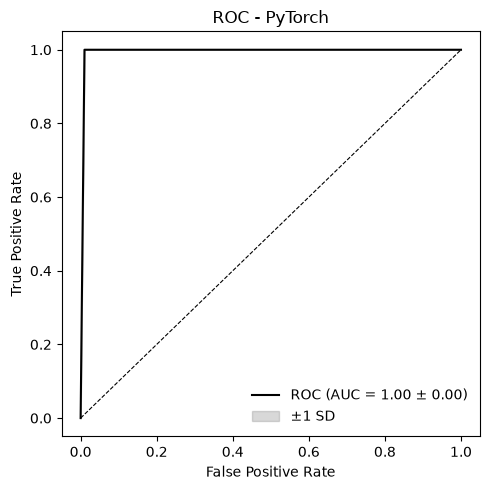

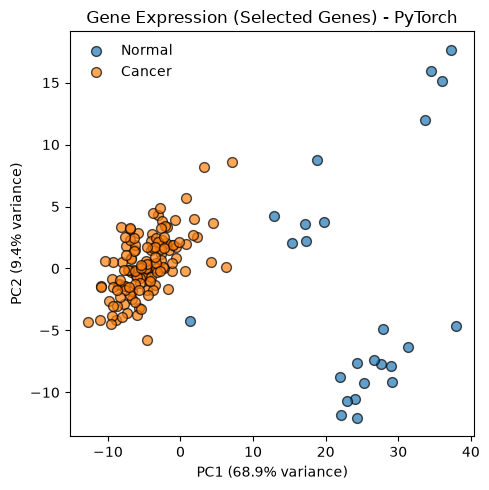

In [6]:
n_bootstraps = 1000
rng = np.random.RandomState(42)
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

for i in range(n_bootstraps):
    indices = rng.randint(0, len(y_test_np), len(y_test_np))
    if len(np.unique(y_test_np[indices])) < 2:
        continue
    fpr, tpr, _ = roc_curve(y_test_np[indices], y_pred_prob_np[indices])
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    tpr_interp = np.interp(mean_fpr, fpr, tpr)
    tpr_interp[0] = 0.0
    tprs.append(tpr_interp)

    # Statistics
mean_tpr = np.mean(tprs, axis=0)
std_tpr = np.std(tprs, axis=0)
mean_auc = np.mean(aucs)
std_auc = np.std(aucs)

# Plot
plt.figure(figsize=(5, 5))
plt.plot(mean_fpr, mean_tpr, color="black",
         label=f"ROC (AUC = {mean_auc:.2f} ± {std_auc:.2f})")

plt.fill_between(
    mean_fpr,
    np.maximum(mean_tpr - std_tpr, 0),
    np.minimum(mean_tpr + std_tpr, 1),
    color="gray",
    alpha=0.3,
    label="±1 SD"
)

plt.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=0.8)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC - PyTorch")
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig("docs/results_photos_torch/roc_curve.png")
plt.show()

# Transform the FULL dataset using your fitted selector + scaler (from the main train/test split)
X_all_sel = selector.transform(X)
X_all_scaled = scaler.transform(X_all_sel)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_all_scaled)

pc1_var = pca.explained_variance_ratio_[0] * 100
pc2_var = pca.explained_variance_ratio_[1] * 100

# Plot
plt.figure(figsize=(5, 5))

plt.scatter(
    X_pca[y == 0, 0],
    X_pca[y == 0, 1],
    label="Normal",
    alpha=0.7,
    edgecolor="black",
    s=50
)

plt.scatter(
    X_pca[y == 1, 0],
    X_pca[y == 1, 1],
    label="Cancer",
    alpha=0.7,
    edgecolor="black",
    s=50
)

plt.xlabel(f"PC1 ({pc1_var:.1f}% variance)")
plt.ylabel(f"PC2 ({pc2_var:.1f}% variance)")
plt.title("Gene Expression (Selected Genes) - PyTorch")
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig("docs/results_photos_torch/pca_plot_torch.png")
plt.show()

In [ ]:
import joblib
torch.save(model.state_dict(), "models/torch/training_model.pt")

joblib.dump(selector, "models/torch/training_selector.joblib")
joblib.dump(scaler, "models/torch/training_scaler.joblib")

['models/training_scaler.joblib']